In [13]:
import json
import networkx as nx
import matplotlib.pyplot as plt

In [14]:
def read_json_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        papers = json.load(f)
    return papers

In [15]:
def create_doi_to_keywords_mapping(papers):
    doi_to_keywords = {}
    for paper in papers:
        doi = paper.get("DOI", "")
        keywords = paper.get("KW", [])
        if doi:
            doi_to_keywords[doi] = keywords
    return doi_to_keywords

In [16]:
def create_keyword_network(papers, doi_to_keywords):
    G = nx.DiGraph()  # 创建有向图

    for paper in papers:
        doi = paper.get("DOI", "")  # 当前论文的 DOI
        keywords = paper.get("KW", [])  # 当前论文的关键词
        citations = paper.get("CI", [])  # 参考文献的 DOI 列表

        # 遍历每篇参考文献
        for citation_doi in citations:
            # 如果引用的参考文献 DOI 存在于文件中，则继续处理
            if citation_doi in doi_to_keywords:
                cited_keywords = doi_to_keywords[citation_doi]

                # 参考文献中的关键词指向当前论文的关键词
                for cited_kw in cited_keywords:
                    for kw in keywords:
                        G.add_edge(cited_kw, kw)  # 添加有向边，参考文献关键词 -> 当前论文关键词

    return G

In [31]:
'''def visualize_network(G):
    pos = nx.spring_layout(G)  # 使用 spring 布局绘图
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=10, node_color='lightblue', arrows=True)
    plt.show()'''
import random
def visualize_connected_subgraph(G, num_nodes=10):
    # 获取所有有边的节点
    connected_nodes = set()
    for edge in G.edges():
        connected_nodes.update(edge)  # 将边的两个节点加入集合
    
    # 如果有边的节点数量不足 num_nodes，选择所有
    if len(connected_nodes) < num_nodes:
        selected_nodes = list(connected_nodes)
    else:
        # 从网络中随机选取一条边，扩展到包含 num_nodes 的连通子图
        initial_node = random.choice(list(connected_nodes))
        selected_nodes = {initial_node}
        
        for neighbor in nx.bfs_edges(G, source=initial_node):
            if len(selected_nodes) >= num_nodes:
                break
            selected_nodes.update(neighbor)

    # 获取所选节点的子图
    subgraph = G.subgraph(selected_nodes)
    
    # 绘制子图
    pos = nx.spring_layout(subgraph)  # 使用 spring 布局绘制子图
    nx.draw(subgraph, pos, with_labels=True, node_size=500, font_size=10, node_color='lightblue', arrows=True)
    plt.show()

In [18]:
def compute_in_out_degrees(G):
    degree_list = []

    for node in G.nodes():
        in_degree = G.in_degree(node)  # 计算入度
        out_degree = G.out_degree(node)  # 计算出度
        degree_list.append({
            node: {
                "入度": in_degree,
                "出度": out_degree
            }
        })

    return degree_list

In [19]:
def save_in_out_degrees_to_json(degree_list, output_path):
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(degree_list, f, ensure_ascii=False, indent=4)
    print(f"节点的入度和出度已保存到 {output_path}")

In [20]:
json_file_path = "wos_CS.json"  # 替换为 JSON 文件路径
degree_output_path = "keyWord_citeNetwork.json"

# 读取论文列表
papers = read_json_file(json_file_path)

In [21]:
doi_to_keywords = create_doi_to_keywords_mapping(papers)

In [22]:
keyword_network = create_keyword_network(papers, doi_to_keywords)

KeyboardInterrupt: 

In [11]:
visualize_network(keyword_network)

KeyboardInterrupt: 

In [12]:
in_out_degrees_list = compute_in_out_degrees(keyword_network)

In [13]:
save_in_out_degrees_to_json(in_out_degrees_list, degree_output_path)

节点的入度和出度已保存到 /hy-tmp/pattern/keyWord_citeNetwork.json


In [23]:
papers_2010 = []
papers_2011 = []
papers_2012 = []
papers_2013 = []
papers_2014 = []
papers_2015 = []
papers_2016 = []
papers_2017 = []
papers_2018 = []
papers_2019 = []
papers_2020 = []
papers_2021 = []
papers_2022 = []
papers_2023 = []
lists= [papers_2010,papers_2011,papers_2012,papers_2013,papers_2014,papers_2015,papers_2016,papers_2017,papers_2018,papers_2019,papers_2020,papers_2021,papers_2022,papers_2023]
years = [2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
for item in papers:
    dict = {}
    for idx,year in enumerate(years):
        if item["YE"] == year:
            dict["DOI"]=item["DOI"]
            dict["KW"]=item["KW"]
            dict["CI"]=item["CI"]
            lists[idx].append(dict)
print("j")

j


In [24]:
doi_to_keywords_lists = [{} for _ in range(14)]
print(doi_to_keywords_lists)

[{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}]


In [25]:
for i in range(14):
    doi_to_keywords_lists[i] = create_doi_to_keywords_mapping(lists[i])
print("j")

j


DiGraph with 11606 nodes and 53356 edges


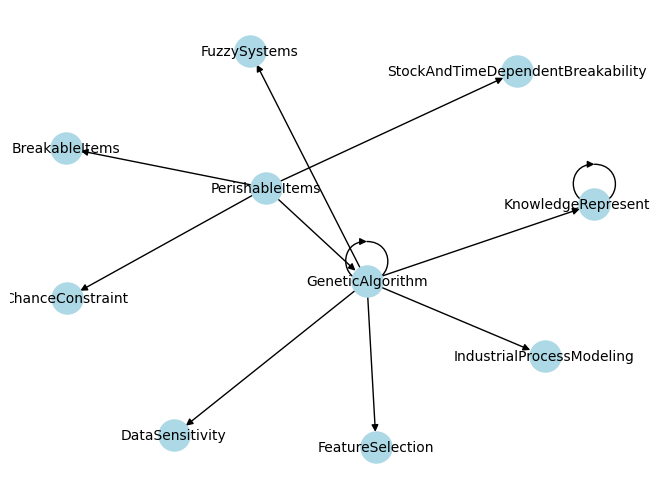

In [33]:
keyword_network_lists = []
for j in range(14):
    keyword_network_lists.append(create_keyword_network(lists[j], doi_to_keywords_lists[j]))
print(keyword_network_lists[0])
visualize_connected_subgraph(keyword_network_lists[0])

In [13]:
in_out_degrees_lists = []
for k in range(14):
    in_out_degrees_lists.append(compute_in_out_degrees(keyword_network_lists[k]))
print(in_out_degrees_lists[0][1])

{'Agent-BasedModelingAndSimulation': {'入度': 4, '出度': 0}}


In [14]:
keyword_network_num = {}
for idx,year_data in enumerate(in_out_degrees_lists):
    for entry in year_data:
        for kw,value in entry.items():
            if kw not in keyword_network_num:
                keyword_network_num[kw] = [[0, 0] for _ in range(14)]
            keyword_network_num[kw][idx][0] = value["入度"]
            keyword_network_num[kw][idx][1] = value["出度"]
save_in_out_degrees_to_json(keyword_network_num, "keyword_network_num.json")

节点的入度和出度已保存到 keyword_network_num.json


[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]]
